# This is a eda of clinic data in navi, mumbai every data collected here are from open resource through google. the excel sheet contains alot of impurities which is handled using Excel and python libaries.

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Clinic Data.xlsx to Clinic Data (4).xlsx


In [2]:
df = pd.read_excel("Clinic Data.xlsx", sheet_name="Cleaning")

In [3]:
df

,Website,Clinic Names,Instagram,Google Maps,Rating,Reviews,Specialization,Location,Contact,Remark 1,Remark 2,Remarks
0,http://www.360homeocareclinic.com/,360 HOMEO CARE CLINIC,Not Found,https://www.google.com/maps/place/360+HOMEO+CA...,5.0,-152.0,Medical clinic,"Shop No. 3, Ganpati Complex, Plot No. 105",NaN,NaN,NaN,
1,https://naneshhospital.com/,Acharya Shri Nanesh Hospital,https://www.instagram.com/naneshhospital,https://www.google.com/maps/place/Acharya+Shri...,4.7,-599.0,Private hospital,Plot No 34-37,+91 86930 84084,NaN,NaN,
2,https://drnevinaabraham.getmy.clinic/,Alpha Dental Clinic,https://www.instagram.com/dr.nevin.abraham,https://www.google.com/maps/place/Alpha+Dental...,5.0,-263.0,Dental clinic,"Shop No.11, Shreeji Seva CHS, Plot No.42",NaN,NaN,NaN,
3,Not Found,Anand Clinic,Not Found,https://www.google.com/maps/place/Anand+Clinic...,5.0,-5.0,Medical clinic,"F-3, Jagatguru Aadi Shankracharya Marg",NaN,"""The","plan was thorough and the results are visible.""","""The plan was thorough and the results are vis..."
4,Not Found,Aniruddha Health Clinic,Not Found,https://www.google.com/maps/place/Aniruddha+He...,NaN,NaN,Medical clinic,"Shop Number 69, Prabhat Centre 1st Floor Plot ...",+91 97696 95873,"""The","is clean, well-organized, and staff is friendl...","""The is clean, well-organized, and staff is fr..."
...,...,...,...,...,...,...,...,...,...,...,...,...
121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""my","was done painlessly and now wi got my fix teeth.""","""my was done painlessly and now wi got my fix ..."
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""I was able to overcome my fear of dental","and felt in safe hands.""","""I was able to overcome my fear of dental and ..."
123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""The staff is compassionate, attentive, and hi...",NaN,"""The staff is compassionate, attentive, and hi..."
124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""The staff is very professional and the therap...",NaN,"""The staff is very professional and the therap..."


In [4]:
df["Reviews"] = df["Reviews"].astype(str).str.replace("-", "", regex=False)

In [5]:
df = df.drop(columns=["Remark 1", "Remark 2"])

In [6]:
def Opportunity_score(row):
    website_missing = row["Website"] == "Not Found"
    instagram_missing = row["Instagram"] == "Not Found"

    if website_missing and instagram_missing:
        return "High"
    elif website_missing or instagram_missing:
        return "Medium"
    else:
        return "Low"

df["Opportunity"] = df.apply(Opportunity_score, axis=1)

In [7]:
def Lead_Category(row):
    website = row["Website"]
    instagram = row["Instagram"]

    if website == "Not Found" and instagram == "Not Found":
        return "Both"
    elif website != "Not Found" and instagram == "Not Found":
        return "Digital marketing"
    elif website == "Not Found" and instagram != "Not Found":
        return "Web development"
    elif website != "Not Found" and instagram != "Not Found":
        return "None"

df["Category"] = df.apply(Lead_Category, axis=1)

In [8]:
df

,Website,Clinic Names,Instagram,Google Maps,Rating,Reviews,Specialization,Location,Contact,Remarks,Opportunity,Category
0,http://www.360homeocareclinic.com/,360 HOMEO CARE CLINIC,Not Found,https://www.google.com/maps/place/360+HOMEO+CA...,5.0,152.0,Medical clinic,"Shop No. 3, Ganpati Complex, Plot No. 105",NaN,,Medium,Digital marketing
1,https://naneshhospital.com/,Acharya Shri Nanesh Hospital,https://www.instagram.com/naneshhospital,https://www.google.com/maps/place/Acharya+Shri...,4.7,599.0,Private hospital,Plot No 34-37,+91 86930 84084,,Low,None
2,https://drnevinaabraham.getmy.clinic/,Alpha Dental Clinic,https://www.instagram.com/dr.nevin.abraham,https://www.google.com/maps/place/Alpha+Dental...,5.0,263.0,Dental clinic,"Shop No.11, Shreeji Seva CHS, Plot No.42",NaN,,Low,None
3,Not Found,Anand Clinic,Not Found,https://www.google.com/maps/place/Anand+Clinic...,5.0,5.0,Medical clinic,"F-3, Jagatguru Aadi Shankracharya Marg",NaN,"""The plan was thorough and the results are vis...",High,Both
4,Not Found,Aniruddha Health Clinic,Not Found,https://www.google.com/maps/place/Aniruddha+He...,NaN,nan,Medical clinic,"Shop Number 69, Prabhat Centre 1st Floor Plot ...",+91 97696 95873,"""The is clean, well-organized, and staff is fr...",High,Both
...,...,...,...,...,...,...,...,...,...,...,...,...
121,NaN,NaN,NaN,NaN,NaN,nan,NaN,NaN,NaN,"""my was done painlessly and now wi got my fix ...",Low,None
122,NaN,NaN,NaN,NaN,NaN,nan,NaN,NaN,NaN,"""I was able to overcome my fear of dental and ...",Low,None
123,NaN,NaN,NaN,NaN,NaN,nan,NaN,NaN,NaN,"""The staff is compassionate, attentive, and hi...",Low,None
124,NaN,NaN,NaN,NaN,NaN,nan,NaN,NaN,NaN,"""The staff is very professional and the therap...",Low,None


In [9]:
df.to_excel("Cleaned.xlsx", index=False)

In [10]:
from google.colab import files

files.download("Cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# The file contained some extra characters repeated in every line with were automatically removed by this code. i used two column to make remarks so i needed to use python to drop them, Next i need to classify lead category and oppurtunity using available details on website and instagram now i would need to download and alter some changes in excel like to find leads category and opportunity in each clinics.

# Now using matplotlib to visualize some important information for sales team most of the clinics lack proper online visibility and proper website and i found most of the contact of these company whcih means there is more change for lead oppurtunity, Majority clinic types are medical, skincare, dental, derma and ayuveda.

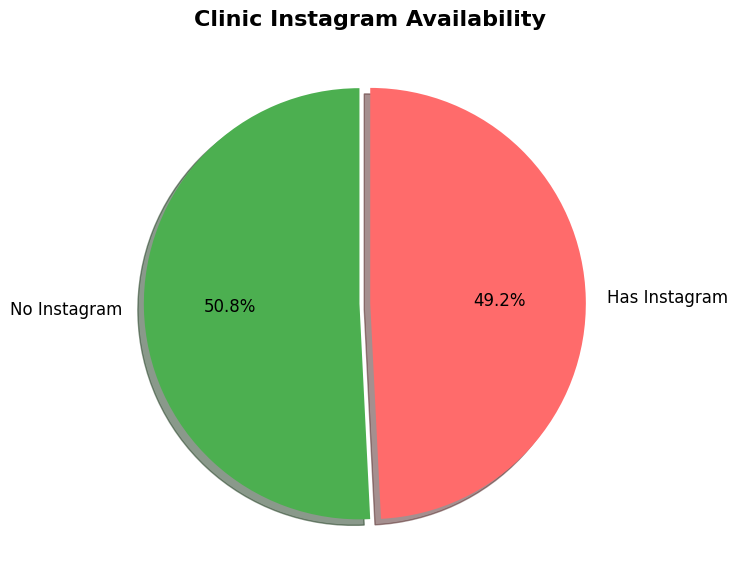

In [25]:

instagram = df["Instagram"].apply(
    lambda x: "Has Instagram" if x != "Not Found" else "No Instagram"
).value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    instagram,
    labels=instagram.index,
    autopct="%1.1f%%",
    colors=["#4CAF50", "#FF6B6B"],
    startangle=90,
    explode=(0.05, 0),
    shadow=True,
    textprops={"fontsize": 12}
)

plt.title("Clinic Instagram Availability", fontsize=16, fontweight="bold")

plt.show()

Text(0.5, 1.0, 'Clinic Website Availability')

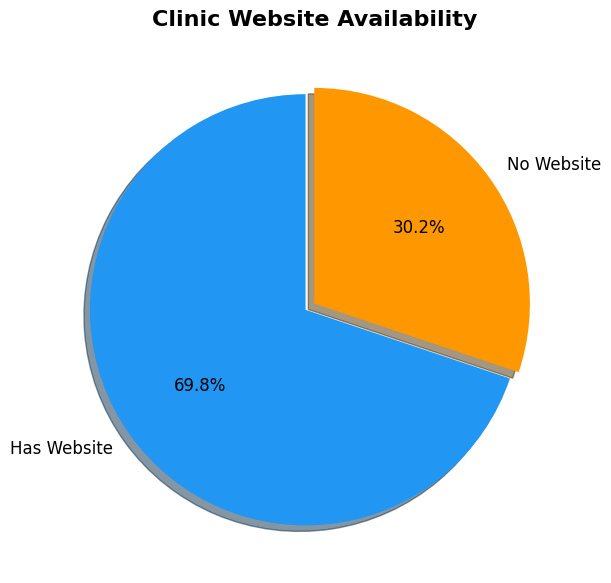

In [26]:
website = df["Website"].apply(
    lambda x: "Has Website" if x != "Not Found" else "No Website"
).value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    website,
    labels=website.index,
    autopct="%1.1f%%",
    colors=["#2196F3", "#FF9800"],
    startangle=90,
    explode=(0.05, 0),
    shadow=True,
    textprops={"fontsize": 12}
)

plt.title("Clinic Website Availability", fontsize=16, fontweight="bold")


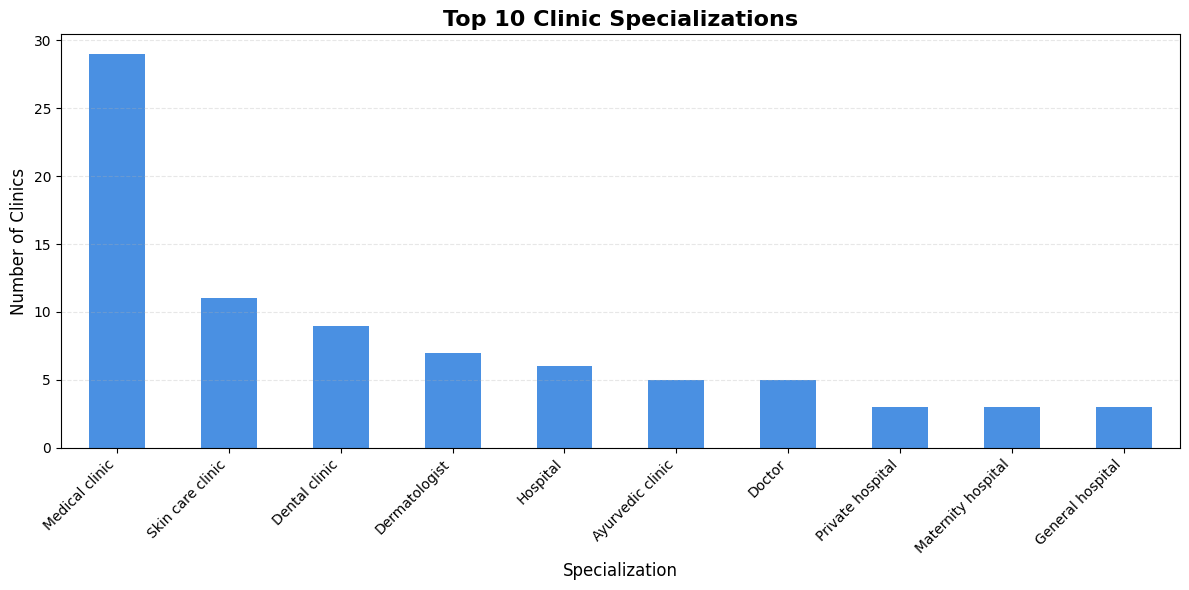

In [27]:
plt.figure(figsize=(12,6))

df["Specialization"].value_counts().head(10).plot(
    kind="bar",
    color="#4A90E2"
)

plt.title("Top 10 Clinic Specializations", fontsize=16, fontweight="bold")
plt.xlabel("Specialization", fontsize=12)
plt.ylabel("Number of Clinics", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

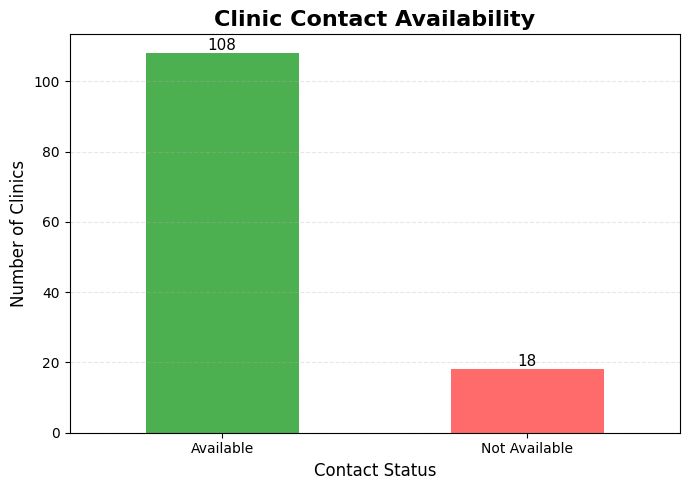

In [28]:
contact = df["Contact"].fillna("Not Available").apply(
    lambda x: "Available" if x not in ["Not Available", "Not Found", ""] else "Not Available"
).value_counts()

plt.figure(figsize=(7,5))

contact.plot(
    kind="bar",
    color=["#4CAF50", "#FF6B6B"]
)

plt.title("Clinic Contact Availability", fontsize=16, fontweight="bold")
plt.xlabel("Contact Status", fontsize=12)
plt.ylabel("Number of Clinics", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Add values on top of bars
for i, value in enumerate(contact):
    plt.text(i, value + 1, str(value), ha="center", fontsize=11)

plt.tight_layout()
plt.show()